# Topic Modeling on 2015 Health News Tweets with BOW & NMF

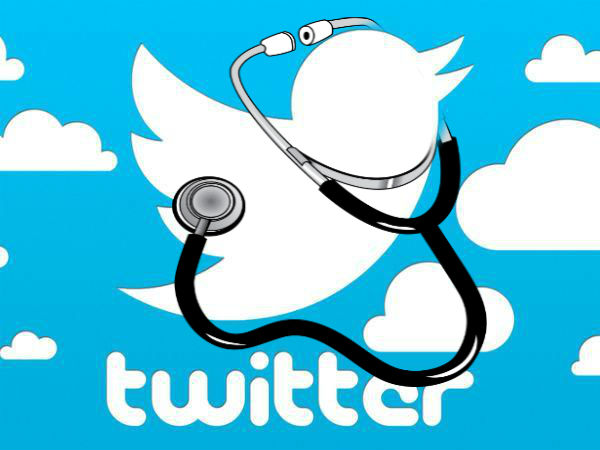

'Credit: Gizbot'

In [1]:
from IPython.display import Image
display(Image(r"pics\09-1436434336-what-your-tweets-tell-about-your-heart-health2.jpg"))
display("Credit: Gizbot")

## Overview of topic modeling

Topic Modeling is an efficient method for analyzing large volumes of text by clustering documents into topics. A large amount of text data is unlabeled. That means we won’t be able to apply supervised learning approaches to create machine learning models, because supervised learning models need historic labelled data in order to make predictions. And in the real world—specifically with text data—you won't always have labels for a text dataset (ie. positive or negative sentiment, spam vs. ham, etc.). Instead you might have a variety of labels such as the different categories that a newspaper article could be in, or you just the (unlabeled) text itself. It’s up to us to discover those labels through Topic Modeling. 

In the case of text data, this means attempting to discover clusters of documents, grouped together by topics. Keep in mind that we don’t know the correct topic or the right answer. All we know is that the documents clustered together share similar topic ideas. It is up to us to identify what these topics represent.

## Overview of Use Case 

We’re going to conduct Topic Modeling on 2015 Health News Tweets from various news organizations so we can discover the most important Health topics in 2015. BBC, the New York Times, CNN, the LA Times are some of the news organizations included in these tweets.

In the healthcare setting, medical information such as medical condition, medication, dosage, strength, and frequency are often “trapped” in a variety of sources like doctors’ notes, clinical trial reports, and patient health records.  Topic Modeling allows us to learn more about the topics that are hidden in a corpus of documents without having to parse through every single document - as this is very time consuming and it doesn't work at scale.

In [2]:
import glob
import random
import os
import pandas as pd

import spacy
nlp = spacy.load('en_core_web_sm')
stop_words = nlp.Defaults.stop_words

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
from gensim.corpora.dictionary import Dictionary
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize

C:\Users\wilscardino\AppData\Local\Continuum\anaconda3\lib\site-packages\gensim\utils.py:1197: UserWarning: detected Windows; aliasing chunkize to chunkize_serial
  warnings.warn("detected Windows; aliasing chunkize to chunkize_serial")


## About the data - 2015 Health News Tweets
The 2015 Health News Tweets dataset is available via the UCI Machine Learning Repository. Link here
https://archive.ics.uci.edu/ml/datasets/Health+News+in+Twitter

Each file is related to one Twitter account of a news agency (ie. "bbchealth" is related to BBC health news). Each row contains the tweet. This text data has been used to evaluate the performance of topic models on short text data. It can also be used for other tasks such as clustering.

Below you can see all of the news organizations in this dataset. 

In [3]:
all_files_txt = glob.glob(r"data/*.txt")
df = pd.concat((pd.read_csv(f,names=['hash','time','tweet'], delimiter='|',encoding = "ISO-8859-1").assign(news_agency=os.path.basename(f).replace('.txt','')) for f in all_files_txt), ignore_index=True)
df.drop('hash',axis=1,inplace=True)
display(set(df['news_agency']))

{'KaiserHealthNews',
 'NBChealth',
 'bbchealth',
 'cbchealth',
 'cnnhealth',
 'foxnewshealth',
 'gdnhealthcare',
 'latimeshealth',
 'msnhealthnews',
 'nprhealth',
 'nytimeshealth',
 'reuters_health',
 'wsjhealth'}

Below you can see the text of 5 tweets from the Guardian:

In [4]:
display(df[df['news_agency']=='gdnhealthcare']['tweet'].head())

13727    Are you a member of the network? Sign up here ...
13728    What is palliative care like in India? One GP ...
13729    Most viewed this week: I loved being a midwife...
13730    How can technology improve mental health waiti...
13731    In case you missed it: Why the #NHS shouldnâ...
Name: tweet, dtype: object

## Simple topic identification – Bag of Words (BOW)

Using one of the most basic NLP models, first we will identify topics based on term frequencies. The first model we're going to use is the Bag of Words (BOW) model.

In Python we wil implement this model using NLTK and Gensim:

1.	Perform text preprocessing (lowercase, remove non-alphabetic characters, remove stop words, and lemmatize) 
2.	Create word tokens
3.	Then count up all the tokens

The more frequent a word, the more important it might be to the text. BOW is a great way to determine the significant words in a text based on the number of times those words are used.

In [5]:
# split on 'http://' to split tweets and urls into separate columns
new = df['tweet'].str.split('http://',n = 1,expand = True)
df['tweet']= new[0] 
df["url"]= new[1] 
del new

In [6]:
# add custom tokens to stopwords
stop_words = nlp.Defaults.stop_words
for word in ['rt','stefaniei','video','new','d','workload','say','RT','good']:
    stop_words.add(word)

Below you can see the 30 most frequent terms across all the Tweets. We can see that the news articles discussed a variety of topics including Ebola, studies, cancer, drugs, patient care, doctors, hospitals, woman, heart disease, insurance, food, and children. We can also see that the top word is "Health." 

In [7]:
# Tokenize the article: tokens
tokens = word_tokenize(str(df['tweet'].tolist()))

# Convert the tokens into lowercase: lower_tokens
lower_tokens = [t.lower() for t in tokens]

# Retain alphabetic words: alpha_only
alpha_only = [t for t in lower_tokens if t.isalpha()]

# Remove all stop words: no_stops
no_stops = [t for t in alpha_only if t not in stop_words]

# Lemmatize all tokens into a new list: lemmatized
lemmatized = [WordNetLemmatizer().lemmatize(t) for t in no_stops]

# Create the bag-of-words: bow
bow = Counter(lemmatized)

# Print the 30 most common tokens
print(bow.most_common(30))   

[('health', 4242), ('ebola', 3677), ('study', 2549), ('cancer', 2110), ('say', 2040), ('drug', 2021), ('patient', 1923), ('care', 1585), ('risk', 1574), ('doctor', 1401), ('help', 1401), ('hospital', 1350), ('find', 1261), ('nh', 1214), ('report', 1133), ('amp', 1057), ('case', 994), ('kid', 994), ('today', 978), ('woman', 976), ('death', 930), ('law', 883), ('heart', 876), ('people', 875), ('insurance', 825), ('life', 800), ('food', 799), ('disease', 795), ('year', 794), ('child', 792)]


Now onto a slightly more complex method for Topic Modeling, known as Non-negative matrix factorization.

## Non-negative matrix factorization (NMF)

Non-negative matrix factorization (NMF) is an unsupervised learning algorithm that simultaneously performs dimensionality reduction and clustering.  We can use it in conjunction with Term-frequency / Inverse document-frequency (Tf-Idf) to model topics across the Tweets. 

Inputs:

•	Non-negative data matrix (A)

    o	In this case A will be Tf-Idf: The term-frequency / inverse-document frequency for the documents vs. the actual 
    words across all the Tweets.

•	number of basis vectors (K)
    
    o	Choose the number of basis vectors (K).  In our case for topic modeling, K is going to be the number of clusters or topics we decide to discover.
    
•	initial values for factors W and H (random matrices)

Here’s how the NMF algorithm works:

1.	Given a non-negative matrix A, find the K-dimension approximation in terms of 2 non-negative factors W and H

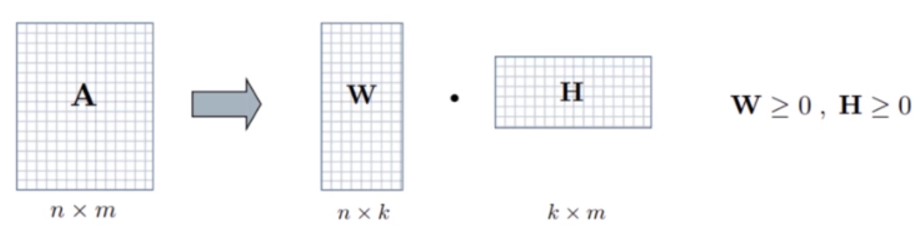

In [8]:
display(Image(r"pics\NMF1.png"))

2.	Then approximate each observation of A by a linear combination of K-reduced dimensions or basis vectors in W.

3.	Perform factorization to approximate A with the matrix multiplication of W and H. 

4.	Initialize the values for W & H with random matrices.  

5.	Get the objective function, which is the measure of reconstruction error between A and the approximation of WH.

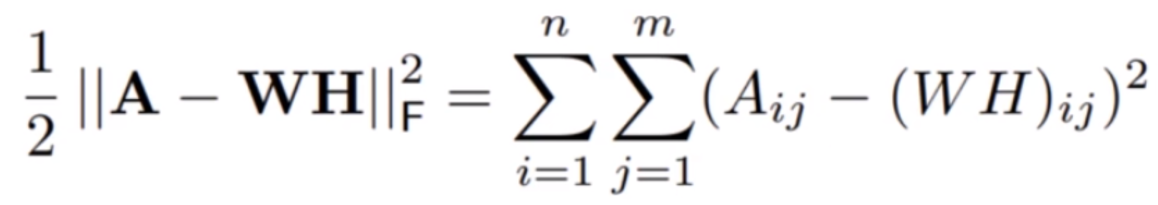

In [9]:
display(Image(r"pics\NMF2.png"))

6.	The Expectation-maximization optimization will iterate between W and H in order to minimize that objective function. The coefficients will continue to update until the approximation of WH makes sense for A.

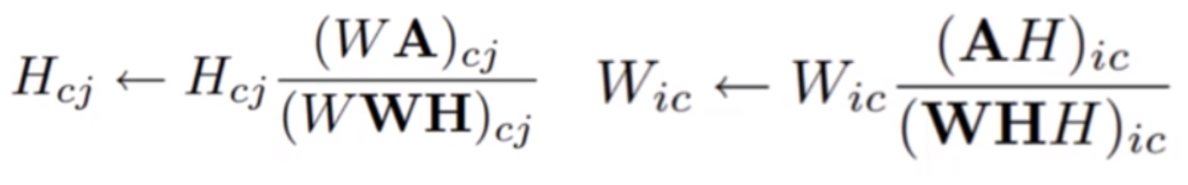

In [10]:
display(Image(r"pics\NMF3.png"))

In Python we will use Sci-kit Learn's Tf-Idf Vectorizer and NMF model:

1.	Construct a vector space model for Tweets (similar output from the text pre-processing techniques that we used for our BOW model), resulting in a document-term matrix A.

2.	Apply Tf-Idf term weight normalization to A

3.	Normalize Tf-Idf vectors to unit length (Both of these steps will be implemented using Sci-kit Learn’s TfidfVectorizer. We will also normalize using Sci-kit Learn's normalize preprocessing).

In [11]:
# Initialize a TfidfVectorizer object: tfidf
tfidf = TfidfVectorizer(sublinear_tf=True, 
                        min_df=5, 
                        smooth_idf=False, 
                        encoding='latin-1', 
                        ngram_range=(1, 2), 
                        stop_words='english')

In [12]:
# perform text preprocessing similarly as before
tweets = df['tweet'].str.split().apply(lambda x: [t.lower() for t in x if t.isalpha() and t not in stop_words]).apply(' '.join)

# create document-term matrix
dtm = tfidf.fit_transform(tweets)

# normalize document-term matrix
dtm_norm = normalize(dtm,norm='l1',axis=1)

In [13]:
# display the shape of the document-term matrix
display(dtm.shape)

(50617, 9808)

In [14]:
# display a random word
display(tfidf.get_feature_names()[random.randint(0,9808)])

'weight gain'

4.	Choose the number of topics (here we chose 6 topics) and initialize factors using Non-negative Double Singular Value Decomposition (NNDSVD) on A.

In [15]:
# initialize nmf model
nmf = NMF(n_components=6,init='nndsvd',random_state=42,verbose=1)

5.	Apply Projected Gradient NMF to A.

What we end up discovering are the topics in the data and the the membership weights for documents relative to each topic. 

In [16]:
# fit the model
nmf.fit(dtm_norm)

violation: 1.0
violation: 0.29249750460212004
violation: 0.10362119128156934
violation: 0.0551270813249422
violation: 0.03685549216031335
violation: 0.02532684910122505
violation: 0.01764413571997553
violation: 0.012718317724074292
violation: 0.00937607858604088
violation: 0.007077817277927931
violation: 0.005466395083876841
violation: 0.0043097327867340305
violation: 0.0034619732838794596
violation: 0.0028314551826232512
violation: 0.002351307557486613
violation: 0.0019752420966972235
violation: 0.001674595578224022
violation: 0.0014315332379320213
violation: 0.0012349015551381677
violation: 0.0010709327344473679
violation: 0.0009339385241951607
violation: 0.0008193999169454526
violation: 0.000722366287297169
violation: 0.000639588694783776
violation: 0.0005689821956956748
violation: 0.0005098688473850817
violation: 0.00045881694927133257
violation: 0.00041428747059539566
violation: 0.00037524288673081846
violation: 0.00034093155791587376
violation: 0.00031089464500456883
violation: 0

NMF(alpha=0.0, beta_loss='frobenius', init='nndsvd', l1_ratio=0.0,
  max_iter=200, n_components=6, random_state=42, shuffle=False,
  solver='cd', tol=0.0001, verbose=1)

Below you can see the top 20 words that have the highest coefficient values.
It's up to us to interpret what these words mean for a topic:

Topic 0 looks like it has to do with mental health and health insurance.

Topic 1 looks like it has to do with Ebola.

Topic 2 looks like it has to do with cancer (breast, lung and prostate cancer).

Topic 3 looks like it has to do with food and brain health studies.

Topic 4 looks like it has to do with the NHS in the U.K. 

Topic 5 looks like it has to do with old age. 

In [17]:
# grab the top 20 words per topic
for i,topic in enumerate(nmf.components_):
    print(f"Top 20 words for Topic {i}")
    print([tfidf.get_feature_names()[index] for index in topic.argsort()[:-20 - 1:-1]])
    print('\n')

Top 20 words for Topic 0
['health', 'care', 'health care', 'mental', 'insurance', 'mental health', 'law', 'health insurance', 'health law', 'coverage', 'plans', 'exchanges', 'workers', 'obama', 'know', 'health plans', 'new health', 'public', 'recipes', 'officials']


Top 20 words for Topic 1
['ebola', 'outbreak', 'liberia', 'ebola outbreak', 'patient', 'hospital', 'vaccine', 'sierra', 'ebola vaccine', 'africa', 'ebola patient', 'nurse', 'leone', 'west', 'virus', 'fight', 'cases', 'sierra leone', 'says', 'case']


Top 20 words for Topic 2
['cancer', 'breast', 'breast cancer', 'patients', 'drug', 'risk', 'cancer drug', 'cancer patients', 'prostate', 'cancer risk', 'prostate cancer', 'doctor', 'drugs', 'test', 'women', 'lung', 'treatment', 'lung cancer', 'dies', 'skin']


Top 20 words for Topic 3
['study', 'says', 'finds', 'study finds', 'study says', 'brain', 'help', 'kids', 'people', 'women', 'drug', 'risk', 'heart', 'better', 'patients', 'food', 'suggests', 'use', 'doctors', 'study sug

The highest coefficient indicates the first tweet belongs to Topic 2. Recall that Topic 2 had to do with cancer - in this case, breast cancer.

In [18]:
print(df['tweet'][0])

Breast cancer risk test devised 


In [19]:
topic_results = nmf.transform(dtm)
print(topic_results[0])

violation: 1.0
violation: 0.05005468867891297
violation: 0.0005708162260747108
violation: 4.559409196402301e-06
Converged at iteration 4
[0.         0.00037509 0.17362058 0.0021912  0.         0.00114327]
